In [63]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [2]:
path = r"C:\Users\admin\Downloads\archive (6)\Mall_Customers.csv"
df = pd.read_csv(path)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

# Data Preprocessing 

In [66]:
#label encode Gender column into numerical values
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # for male = 1 and female = 0

In [75]:
df.drop("CustomerID", axis=1, inplace=True)

In [76]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,2
3,0,23,16,77,2
4,0,31,17,40,2
...,...,...,...,...,...
195,0,35,120,79,1
196,0,45,126,28,1
197,1,32,126,74,3
198,1,32,137,18,1


In [77]:
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

In [78]:
#convert data to 2D for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

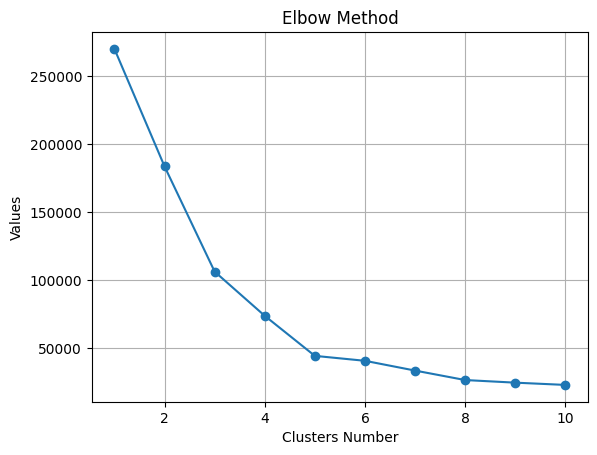

In [79]:
#to find best K
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
inertia = []
k_value = range(1, 11)

for k in k_value:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(k_value, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters Number")
plt.ylabel("Values")
plt.grid(True)
plt.show()

# K-Means Clustering

In [80]:
k_means = KMeans(n_clusters=4, random_state=42)
kmeans_labels = k_means.fit_predict(scaled_df)

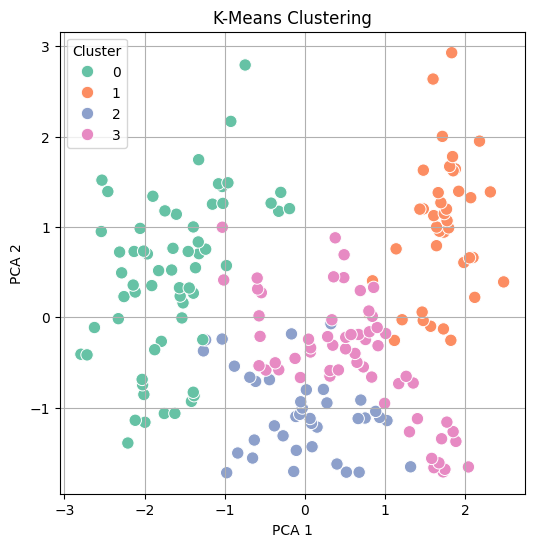

In [82]:
# Plot K-Means Clusters (using full dataset)
plt.figure(figsize=(6,6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=kmeans_labels, palette='Set2',s=80)
plt.title("K-Means Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

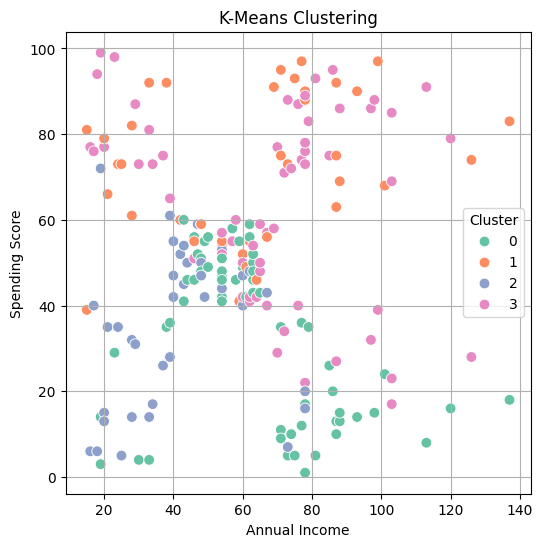

In [84]:
#add cluster labels to the DataFrame
df['Cluster'] = kmeans_labels
# Plot K-Means Clusters (using annual income and spending score columns)
plt.figure(figsize=(6,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='Set2',s=60)
plt.title("K-Means Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Hierarchical Clustering

In [85]:
# Apply Agglomerative Clustering
agglo_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
agglo_labels = agglo_clustering.fit_predict(scaled_df)
y_agglo=agglo.labels_

C:\Users\admin\AppData\Local\Temp\ipykernel_25744\2798590044.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cluster')


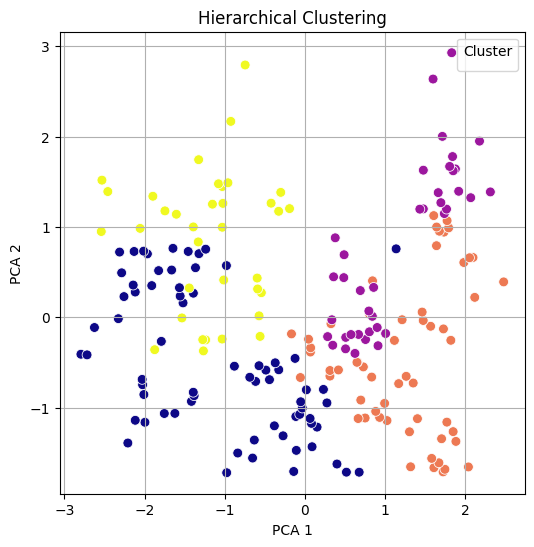

In [86]:
# Plot Hierarchical Clusters
plt.figure(figsize=(6,6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1],c=y_agglo, cmap='plasma', s=50)
plt.title("Hierarchical Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# DBSCAN Clustering

In [87]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_df)

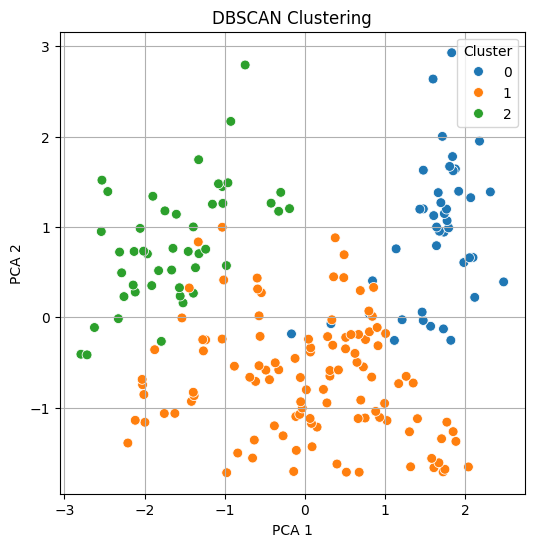

In [88]:
# Plot DBSCAN Clusters
plt.figure(figsize=(6,6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=dbscan_labels, palette='tab10', s=50)
plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()